# The EDA Notebook 

In [4]:
# impors and data loading 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# LOAD DATA (Update the path to your actual CSV file)
df = pd.read_csv('../data/raw/data.csv')

# Convert timestamp to datetime immediately
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# print data loading succesful
print("data loaded successfully")


data loaded successfully


In [5]:
# initial data preview 
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)
display(df.head())

Dataset Shape: (95662, 16)

--- Data Types ---
TransactionId                        object
BatchId                              object
AccountId                            object
SubscriptionId                       object
CustomerId                           object
CurrencyCode                         object
CountryCode                           int64
ProviderId                           object
ProductId                            object
ProductCategory                      object
ChannelId                            object
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[ns, UTC]
PricingStrategy                       int64
FraudResult                           int64
dtype: object


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


In [6]:
# missing values and summary statistics 
print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Numerical Summary ---")
# Focus on Value and Amount
display(df[['Amount', 'Value']].describe())


--- Missing Values ---
TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

--- Numerical Summary ---


,Amount,Value
count,9.566200e+04,9.566200e+04
mean,6.717846e+03,9.900584e+03
std,1.233068e+05,1.231221e+05
min,-1.000000e+06,2.000000e+00
25%,-5.000000e+01,2.750000e+02
50%,1.000000e+03,1.000000e+03
75%,2.800000e+03,5.000000e+03
max,9.880000e+06,9.880000e+06


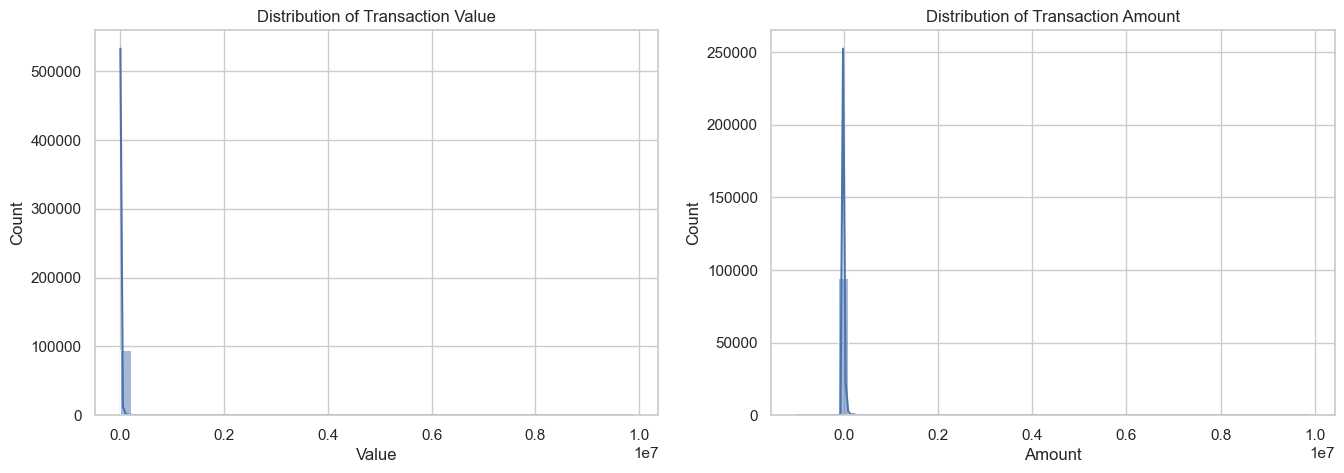

In [7]:
# Distribution of Numerical Features (Visual)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['Value'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Transaction Value')

sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Transaction Amount')

plt.show()

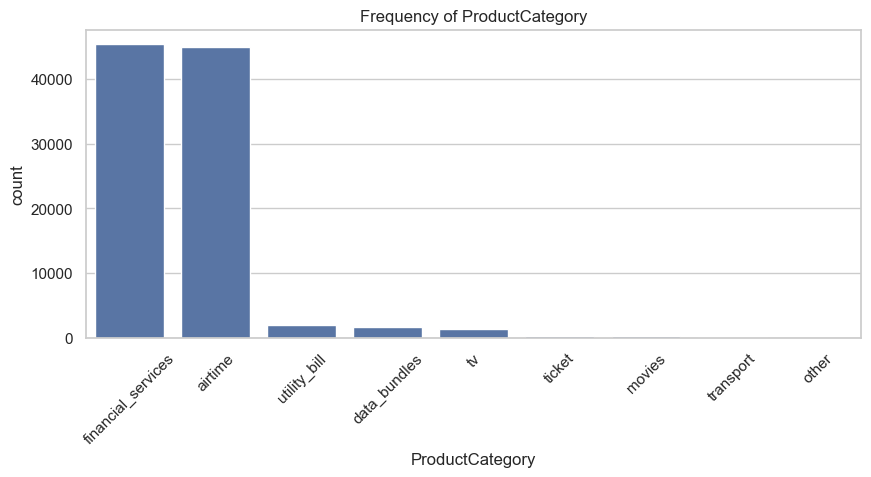

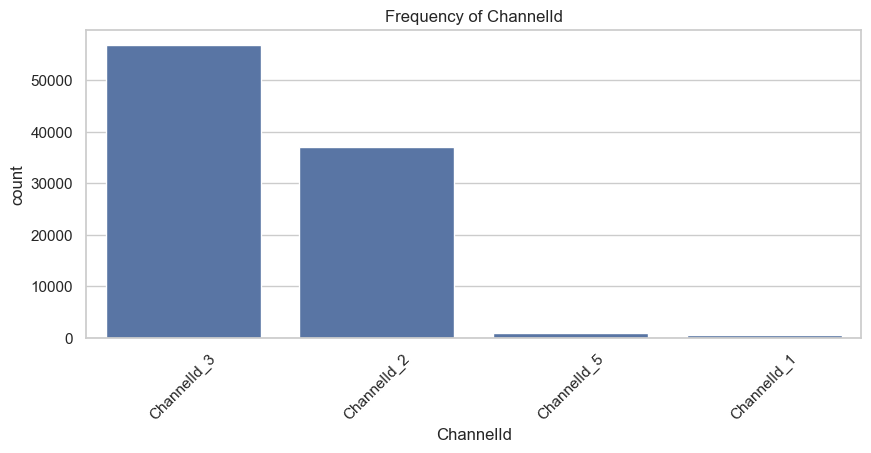

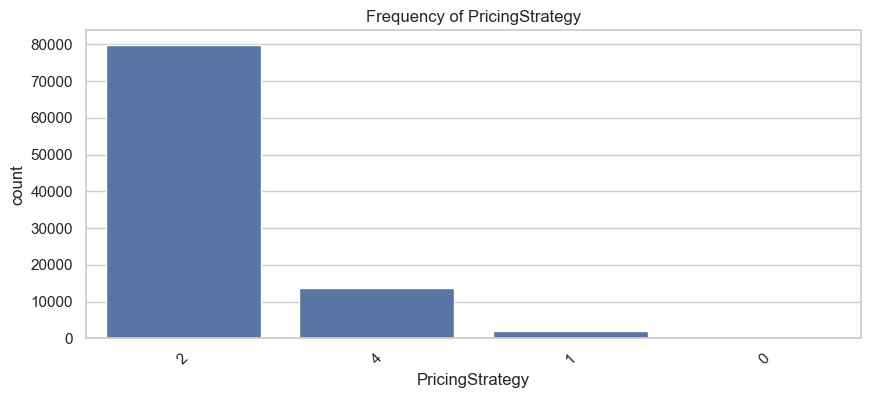

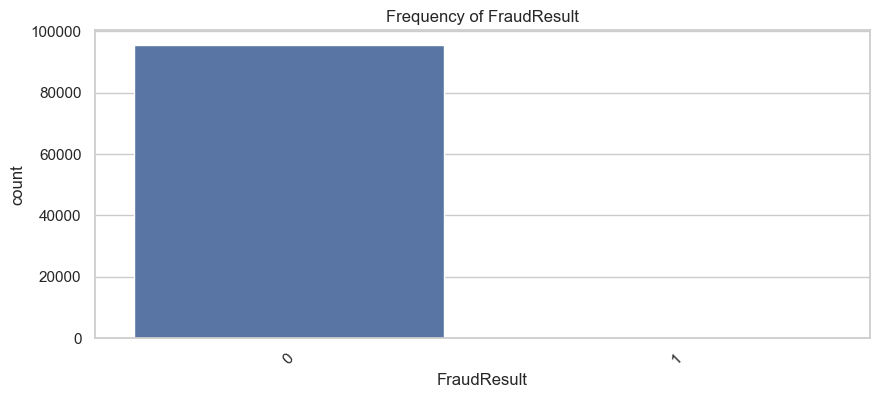

In [8]:
# Distribution of Categorical Features
cat_cols = ['ProductCategory', 'ChannelId', 'PricingStrategy', 'FraudResult']

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Frequency of {col}')
    plt.xticks(rotation=45)
    plt.show()

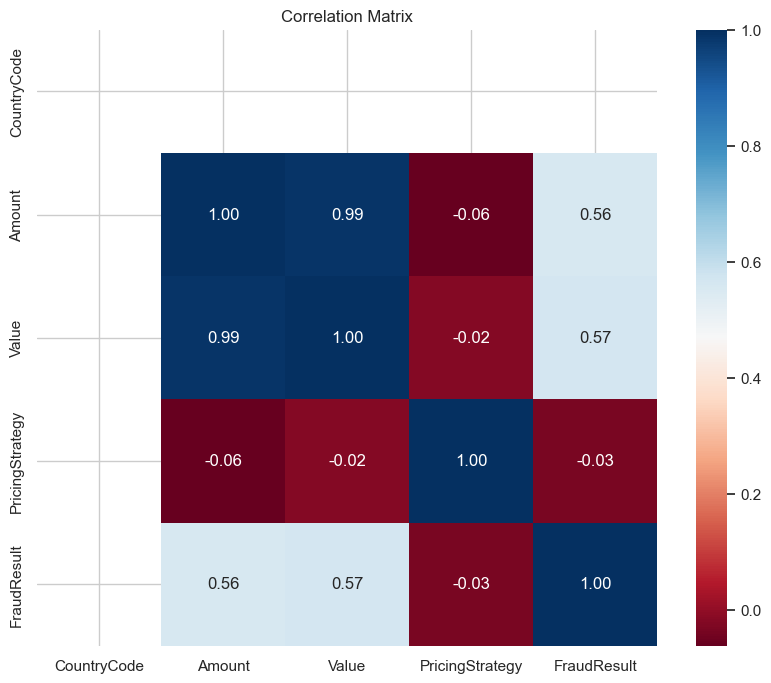

In [9]:
# correaltion Analysis 
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

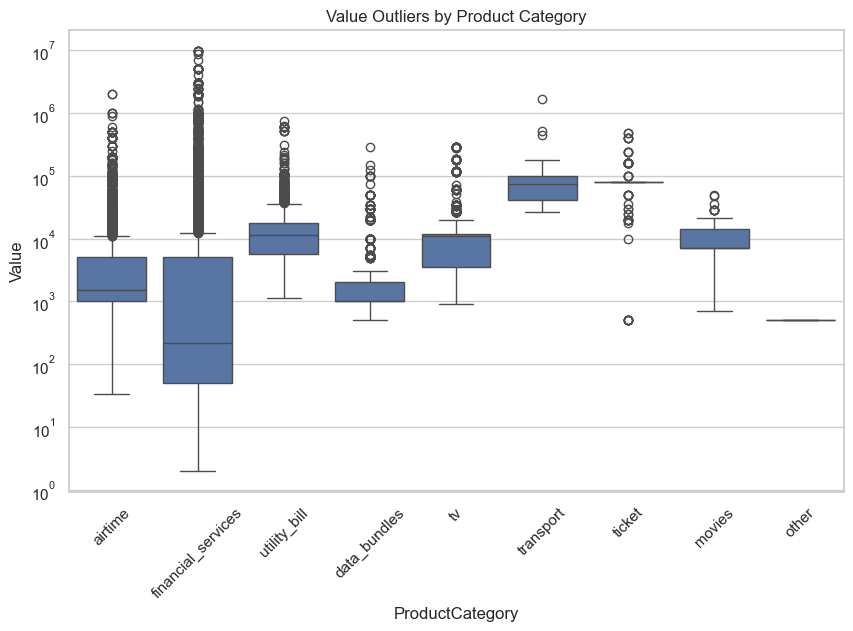

In [10]:
# Outlier Detection (Box Plots)
plt.figure(figsize=(10, 6))
sns.boxplot(x='ProductCategory', y='Value', data=df)
plt.yscale('log') # Using log scale because transactions often have huge outliers
plt.title('Value Outliers by Product Category')
plt.xticks(rotation=45)
plt.show()


---

# Exploratory Data Analysis (EDA) Summary Report

## 1. Dataset Overview & Quality
*   **Volume:** The dataset contains **95,662 transactions** across 16 features.
*   **Data Integrity:** There are **zero missing values** across all fields, indicating a very clean raw dataset.
*   **Redundancy:** `Amount` and `Value` have a correlation of **0.99**. Since `Value` is the absolute magnitude and `Amount` includes the direction (debit/credit), we should use `Value` for monetary scaling and `Amount` to identify transaction types.

## 2. Key Insights & Statistical Observations

### A. Extreme Value Skewness & Outliers
*   **Observation:** Both Transaction `Value` and `Amount` exhibit extreme positive skewness. While the majority of transactions are small (median is likely in the $1,000–$5,000 range), outliers reach as high as **$10,000,000**.
*   **Product Context:** `Financial_Services` and `Airtime` are the most frequent categories, but `Financial_Services` contains the most significant outliers. `Transport` and `Ticket` categories have higher median values but much lower transaction volumes.
*   **Risk Implication:** High-value outliers in `Financial_Services` are prime candidates for default risk analysis. We should apply **log-transformation** or **Robust Scaling** to these features before modeling to prevent outliers from dominating the learning process.

### B. Categorical Dominance
*   **Channel Preference:** `ChannelId_3` and `ChannelId_2` account for the vast majority of transactions. Users on `ChannelId_1` and `ChannelId_5` are rare, making them potentially unique behavioral segments.
*   **Pricing Strategy:** `PricingStrategy_2` is the standard for nearly 80% of the data. Transactions under `PricingStrategy_0` are negligible.

### C. Fraud & Risk Correlation
*   **Fraud Imbalance:** The `FraudResult` is extremely imbalanced (near-zero frequency for Class 1). 
*   **Correlation Insight:** There is a **0.57 correlation** between `Value` and `FraudResult`. This suggests that as the transaction amount increases, the likelihood of fraud (and therefore credit risk) increases significantly. This validates the use of "Monetary" value as a core component of our proxy risk variable.

---